In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
import torch
from torch_geometric.datasets import PPI

path = './data/PPI'

train_dataset = PPI(root=path, split='train')
val_dataset = PPI(root=path, split='val')
test_dataset = PPI(root=path, split='test')

print(f"Number of training graphs: {len(train_dataset)}")
print(f"Number of validation graphs: {len(val_dataset)}")
print(f"Number of test graphs: {len(test_dataset)}")
print(f"Number of node features: {train_dataset.num_features}")
print(f"Number of classes (labels per node): {train_dataset.num_classes}")

Number of training graphs: 20
Number of validation graphs: 2
Number of test graphs: 2
Number of node features: 50
Number of classes (labels per node): 121


In [12]:
from torch_geometric.loader import DataLoader 
from torch_geometric.utils import to_dense_batch, to_dense_adj 

train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=2, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=2, shuffle=False)

## GCN ##

In [13]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import DenseGCNConv
from torch_geometric.utils import to_dense_batch, to_dense_adj

class StructureLearner(nn.Module):
    def __init__(self, in_features, hidden_dim=128):
        super().__init__()
        # Camada que descobre quais features importam para ligar proteínas
        self.projection = nn.Linear(in_features, hidden_dim)
        
    def forward(self, x, mask):
        # x shape: [Batch, Max_Nodes, Features]
        
        # 1. Projeta para o espaço de similaridade
        z = F.relu(self.projection(x))
        
        # 2. Produto Escalar em Lote (BMM) -> Mede a "química" entre cada par de proteínas
        # learned_adj shape: [Batch, Max_Nodes, Max_Nodes]
        sim_matrix = torch.bmm(z, z.transpose(1, 2))
        learned_adj = torch.sigmoid(sim_matrix)
        
        # 3. CRÍTICO: Matar as ligações fantasmas do padding
        if mask is not None:
            # Transforma a máscara 1D [Batch, N] em 2D [Batch, N, N]
            mask_2d = mask.unsqueeze(-1) * mask.unsqueeze(1)
            # Zera completamente as conexões onde a máscara é Falsa
            learned_adj = learned_adj * mask_2d.float()
            
        return learned_adj

In [17]:
class PPIDynamicGCN(nn.Module):
    def __init__(self, num_features, num_classes):
        super().__init__()
        
        # 1. O nosso gerador de matrizes dinâmicas
        self.learner = StructureLearner(num_features, hidden_dim=128)
        
        # 2. O 'Mixer' - Começa em 0.5 (50% biologia original, 50% rede neural)
        self.alpha = nn.Parameter(torch.tensor([0.0])) 
        
        # 3. GCN Robusta para o PPI
        self.gcn1 = DenseGCNConv(num_features, 256)
        self.gcn2 = DenseGCNConv(256, 256)
        self.gcn3 = DenseGCNConv(256, num_classes)

    def normalize_dynamic_adj(self, adj):
        # A nossa velha amiga normalização, lidando com batches
        B, N, _ = adj.shape
        eye = torch.eye(N, device=adj.device).unsqueeze(0).expand(B, N, N)
        adj_hat = adj + eye
        deg = adj_hat.sum(dim=-1)
        deg_inv_sqrt = deg.pow(-0.5)
        deg_inv_sqrt.masked_fill_(deg_inv_sqrt == float('inf'), 0)
        return deg_inv_sqrt.unsqueeze(-1) * adj_hat * deg_inv_sqrt.unsqueeze(1)

    def forward(self, x, adj_orig, mask):
        # A. A rede inventa as novas ligações
        adj_learned = self.learner(x, mask)
        
        # B. Misturamos a matriz biológica original com a matriz aprendida
        a = torch.sigmoid(self.alpha) # Força o alpha a ficar entre 0 e 1
        adj_combined = (a * adj_orig) + ((1 - a) * adj_learned)
        
        # C. Normalizamos a matriz híbrida
        adj_norm = self.normalize_dynamic_adj(adj_combined)
        
        # D. Passagem Convencional
        x = self.gcn1(x, adj_norm, mask, add_loop=False)
        x = F.relu(x)
        x = F.dropout(x, p=0.2, training=self.training)
        
        x = self.gcn2(x, adj_norm, mask, add_loop=False)
        x = F.relu(x)
        x = F.dropout(x, p=0.2, training=self.training)
        
        x = self.gcn3(x, adj_norm, mask, add_loop=False)
        
        return x, adj_learned # Retornamos a matriz aprendida para aplicar a penalização no treino!

In [ ]:
import copy
from sklearn.metrics import f1_score

def train(model, optimizer, criterion):
    model.train()
    total_loss = 0
    
    for data in train_loader:
        data = data.to("cuda")
        optimizer.zero_grad()
        
        x_dense, mask = to_dense_batch(data.x, data.batch)
        adj_orig = to_dense_adj(data.edge_index, data.batch)
        
        out, adj_learned = model(x_dense, adj_orig, mask)
        
        out_real = out[mask]
        
        cls_loss = criterion(out_real, data.y)
        

        l1_penalty = adj_learned.sum() / mask.sum() 
        

        loss = cls_loss + (0.001 * l1_penalty)
        
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item() * data.num_graphs
        
    return total_loss / len(train_loader.dataset)

@torch.no_grad()
def evaluate(model, criterion, loader):
    model.eval()
    y_true, y_pred = [], []
    total_loss = 0
    
    for data in loader:
        data = data.to("cuda")
        x_dense, mask = to_dense_batch(data.x, data.batch)
        adj_orig = to_dense_adj(data.edge_index, data.batch)
        
        out, _ = model(x_dense, adj_orig, mask)
        out_real = out[mask]
        
        loss = criterion(out_real, data.y)
        total_loss += loss.item() * data.num_graphs
        
        probs = torch.sigmoid(out_real)
        preds = (probs > 0.5).float()
        
        y_true.append(data.y.cpu().numpy())
        y_pred.append(preds.cpu().numpy())
        
    import numpy as np
    y_true = np.concatenate(y_true, axis=0)
    y_pred = np.concatenate(y_pred, axis=0)
    f1 = f1_score(y_true, y_pred, average='micro')
    
    return total_loss / len(loader.dataset), f1

In [ ]:
model_gcn = PPIDynamicGCN(num_features=train_dataset.num_features, num_classes=train_dataset.num_classes)
model_gcn.to(device="cuda")

criterion = torch.nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model_gcn.parameters(), lr=0.005)

train_losses = []
val_losses = []
val_f1 = []

best_val_acc = 0.0
best_weights = None
best_epoch = 0

for epoch in range(200):
    loss = train(model_gcn, optimizer, criterion)
    
    val_los,val_score_f1 = evaluate(model_gcn,criterion,val_loader)
    
    train_losses.append(loss)
    val_losses.append(val_los) 
    val_f1.append(val_score_f1)
    
    if epoch % 10 == 0:
        print(f'Epoch {epoch:>3} | Loss: {loss:.2f} | ValLoss: {val_los:.2f} | ValF1: {val_score_f1:.2f}')
    


Epoch   0 | Loss: 2.29 | ValLoss: 0.55 | ValF1: 0.40
Epoch  10 | Loss: 1.87 | ValLoss: 0.54 | ValF1: 0.38


KeyboardInterrupt: 

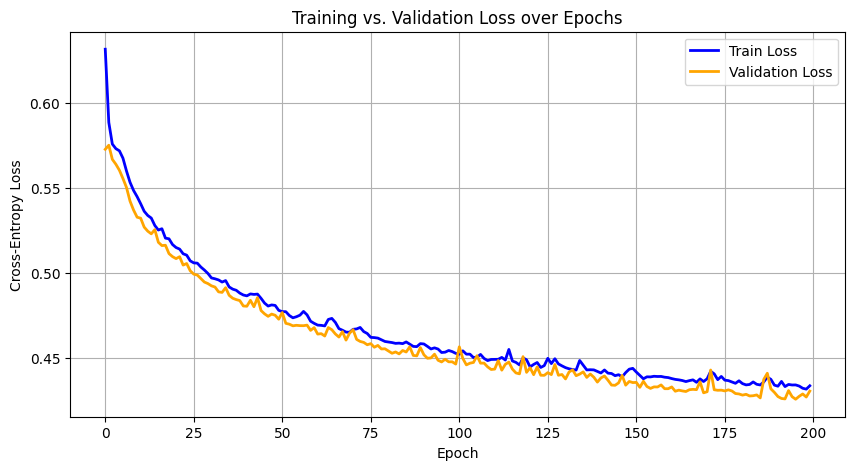

In [39]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss', color='blue', linewidth=2)
plt.plot(val_losses, label='Validation Loss', color='orange', linewidth=2)
plt.title('Training vs. Validation Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Cross-Entropy Loss')
plt.legend()
plt.grid(True)
plt.show()

In [41]:
def test(model, loader):
    model.eval()
    y_true = []
    y_pred = []

    with torch.no_grad():
        for data in loader:
            data = data.to("cuda")
            
            x_dense, mask = to_dense_batch(data.x, data.batch)
            adj_dense = to_dense_adj(data.edge_index, data.batch)
            
            adj_dense = normalize_dense_adj(adj_dense)
            
            out = model(x_dense, adj_dense, mask)
            
            out_real = out[mask]
            
            probs = torch.sigmoid(out_real)
            preds = (probs > 0.5).float()
            
            y_true.append(data.y.cpu().numpy())
            y_pred.append(preds.cpu().numpy())

    y_true = np.concatenate(y_true, axis=0)
    y_pred = np.concatenate(y_pred, axis=0)
    
    return f1_score(y_true, y_pred, average='micro')

test_f1 = test(model_gcn, test_loader)
print(f'Test F1 Score: {test_f1:.4f}')

Test F1 Score: 0.6413


## GAT CONV ##

In [81]:
from torch_geometric.nn import GATConv

class GAT(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.gat1 = GATConv(train_dataset.num_features, 128, heads=4) 
        self.gat2 = GATConv(128*4, 128, heads=4)
        self.gat3 = GATConv(128*4, train_dataset.num_classes, heads=6,concat = False)

    def forward(self, x, edge_index):
        x = F.elu(self.gat1(x, edge_index))
        x = F.elu(self.gat2(x, edge_index))
        x = self.gat3(x, edge_index)
        return x

model = GAT()
print(model)


GAT(
  (gat1): GATConv(50, 128, heads=4)
  (gat2): GATConv(512, 128, heads=4)
  (gat3): GATConv(512, 121, heads=6)
)


In [ ]:
import copy

model_gat = GAT()
model_gat.to(device = "cuda")

criterion = torch.nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model_gat.parameters(),lr=0.005)

train_losses = []
val_losses = []
val_f1

best_val_f1 = 0.0
best_weights = None
best_epoch = 0

for epoch in range(200):
    loss = train(model_gat, optimizer, criterion)
    
    val_los, val_f1_score = evaluate(model_gat,criterion)
    
    train_losses.append(loss)
    val_losses.append(val_los)  
    val_f1.append(val_f1_score)
    
    if val_f1_score > best_val_f1:
        best_val_f1 = val_f1_score
        best_weights = copy.deepcopy(model_gat.state_dict())
        best_epoch = epoch
       
    if epoch % 10 == 0:
        print(f'Epoch {epoch:>3} | Loss: {loss:.2f} | ValLoss: {val_los:.2f} | ValF1: {val_f1_score:.2f}')

model_gat.load_state_dict(best_weights)
print(f'Best validation accuracy: {best_val_f1:.4f} at epoch {best_epoch}')


Epoch   0 | Loss: 0.58 | ValLoss: 0.54 | ValF1: 0.42
Epoch  10 | Loss: 0.46 | ValLoss: 0.45 | ValF1: 0.58
Epoch  20 | Loss: 0.41 | ValLoss: 0.42 | ValF1: 0.62
Epoch  30 | Loss: 0.33 | ValLoss: 0.36 | ValF1: 0.72
Epoch  40 | Loss: 0.28 | ValLoss: 0.34 | ValF1: 0.71
Epoch  50 | Loss: 0.24 | ValLoss: 0.29 | ValF1: 0.78
Epoch  60 | Loss: 0.23 | ValLoss: 0.28 | ValF1: 0.79
Epoch  70 | Loss: 0.20 | ValLoss: 0.26 | ValF1: 0.82
Epoch  80 | Loss: 0.17 | ValLoss: 0.28 | ValF1: 0.82
Epoch  90 | Loss: 0.15 | ValLoss: 0.24 | ValF1: 0.84
Epoch 100 | Loss: 0.16 | ValLoss: 0.24 | ValF1: 0.84
Epoch 110 | Loss: 0.14 | ValLoss: 0.27 | ValF1: 0.81
Epoch 120 | Loss: 0.17 | ValLoss: 0.25 | ValF1: 0.84
Epoch 130 | Loss: 0.12 | ValLoss: 0.23 | ValF1: 0.86
Epoch 140 | Loss: 0.13 | ValLoss: 0.23 | ValF1: 0.86
Epoch 150 | Loss: 0.10 | ValLoss: 0.20 | ValF1: 0.88
Epoch 160 | Loss: 0.10 | ValLoss: 0.21 | ValF1: 0.88
Epoch 170 | Loss: 0.10 | ValLoss: 0.22 | ValF1: 0.87
Epoch 180 | Loss: 0.10 | ValLoss: 0.21 | ValF1

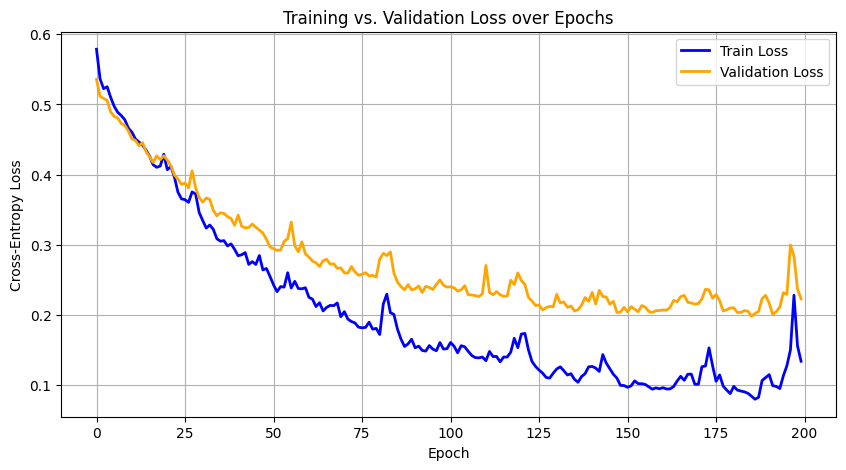

In [84]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss', color='blue', linewidth=2)
plt.plot(val_losses, label='Validation Loss', color='orange', linewidth=2)
plt.title('Training vs. Validation Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Cross-Entropy Loss')
plt.legend()
plt.grid(True)
plt.show()

In [87]:
test_f1 = test(model_gat)
print(f'Test Accuracy: {test_f1:.4f}')

Test Accuracy: 0.9188


In [80]:
import torch
import gc

# Deleta o modelo antigo da memória do Python (substitua o nome se for diferente)
if 'model_gat' in globals():
    del model_gat

# Força o coletor de lixo do Python
gc.collect()

# Limpa o cache da placa de vídeo
torch.cuda.empty_cache()

print("Memória da GPU liberada!")

Memória da GPU liberada!
